The goal of this project is to produce a model that can predict a win, loss, or draw by using historical FIFA data. Then, I want to look at predictive abilities using first half stats (for things like sports betting). This is an ongoing project

Step 0: (I know, I know, I don't want to change all the numbers) import libraries

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

Step 1: Get the data

In [2]:


data_path = ['data/fifa_wc_mens_match_dataset_1970_2022.csv']
    


DATA_PATH = None
for path in data_path:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError('Dataset not found. Try again.')

print('Using dataset path:', DATA_PATH)
all_data = pd.read_csv(DATA_PATH)
all_data.head()



Using dataset path: data/fifa_wc_mens_match_dataset_1970_2022.csv


,tournament_name,stage_name,group_name,group_stage,knockout_stage,replayed,replay,match_date,match_time,stadium_name,city_name,country_name,team_name,team_code,opponent_name,opponent_code,home_team,away_team,goals_for,goals_against,extra_time,penalty_shootout,penalties_for,penalties_against,result,is_host,yellow_cards,red_cards,possession,shots,shots_on_target,passes_completed,passes_attempted,corners,fouls,team_prior_matches,team_prior_win_rate,team_prior_goals_scored_avg,team_prior_goals_conceded_avg,opp_prior_matches,opp_prior_win_rate,opp_prior_goals_scored_avg,opp_prior_goals_conceded_avg,h2h_prior_matches,h2h_prior_win_rate,team_curr_form_pts_avg,team_curr_goals_scored_avg,team_curr_goals_conceded_avg,opp_curr_form_pts_avg,opp_curr_goals_scored_avg,opp_curr_goals_conceded_avg,possession_h1,possession_h2,shots_h1,shots_h2,shots_on_target_h1,shots_on_target_h2,passes_completed_h1,passes_completed_h2,passes_attempted_h1,passes_attempted_h2,corners_h1,corners_h2,fouls_h1,fouls_h2,yellow_cards_h1,yellow_cards_h2,red_cards_h1,red_cards_h2,outcome
0,1970 FIFA Men's World Cup,group stage,Group 1,1,0,0,0,1970-05-31,12:00,Estadio Azteca,Mexico City,Mexico,Mexico,MEX,Soviet Union,SUN,1,0,0,0,0,0,0,0,draw,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17,0.058824,0.764706,2.705882,15,0.533333,1.600000,1.266667,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Draw
1,1970 FIFA Men's World Cup,group stage,Group 1,1,0,0,0,1970-05-31,12:00,Estadio Azteca,Mexico City,Mexico,Soviet Union,SUN,Mexico,MEX,0,1,0,0,0,0,0,0,draw,0,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15,0.533333,1.600000,1.266667,17,0.058824,0.764706,2.705882,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.0,0.0,0.0,Draw
2,1970 FIFA Men's World Cup,group stage,Group 2,1,0,0,0,1970-06-03,16:00,La Bombonera,Toluca,Mexico,Sweden,SWE,Italy,ITA,0,1,0,1,0,0,0,0,lose,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,0.500000,2.375000,2.187500,20,0.600000,1.900000,1.100000,1,1.0,0.0,0.0,0.0,3.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Loss
3,1970 FIFA Men's World Cup,group stage,Group 3,1,0,0,0,1970-06-03,16:00,Estadio Jalisco,Guadalajara,Mexico,Brazil,BRA,Czechoslovakia,CSK,1,0,4,1,0,0,0,0,win,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32,0.625000,2.625000,1.312500,19,0.421053,1.578947,1.526316,4,0.5,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,Win
4,1970 FIFA Men's World Cup,group stage,Group 3,1,0,0,0,1970-06-06,16:00,Estadio Jalisco,Guadalajara,Mexico,Romania,ROU,Czechoslovakia,CSK,1,0,2,1,0,0,0,0,win,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0.200000,1.600000,2.400000,19,0.421053,1.578947,1.526316,1,0.0,0.0,0.0,1.0,0.0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,Win


Step 2: Check dataframe info

In [3]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 70 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tournament_name                1322 non-null   str    
 1   stage_name                     1322 non-null   str    
 2   group_name                     1322 non-null   str    
 3   group_stage                    1322 non-null   int64  
 4   knockout_stage                 1322 non-null   int64  
 5   replayed                       1322 non-null   int64  
 6   replay                         1322 non-null   int64  
 7   match_date                     1322 non-null   str    
 8   match_time                     1322 non-null   str    
 9   stadium_name                   1322 non-null   str    
 10  city_name                      1322 non-null   str    
 11  country_name                   1322 non-null   str    
 12  team_name                      1322 non-null   str    
 13 

Step 3: View all column names in the data

In [4]:
for col in all_data.columns:
    print(col)

tournament_name
stage_name
group_name
group_stage
knockout_stage
replayed
replay
match_date
match_time
stadium_name
city_name
country_name
team_name
team_code
opponent_name
opponent_code
home_team
away_team
goals_for
goals_against
extra_time
penalty_shootout
penalties_for
penalties_against
result
is_host
yellow_cards
red_cards
possession
shots
shots_on_target
passes_completed
passes_attempted
corners
fouls
team_prior_matches
team_prior_win_rate
team_prior_goals_scored_avg
team_prior_goals_conceded_avg
opp_prior_matches
opp_prior_win_rate
opp_prior_goals_scored_avg
opp_prior_goals_conceded_avg
h2h_prior_matches
h2h_prior_win_rate
team_curr_form_pts_avg
team_curr_goals_scored_avg
team_curr_goals_conceded_avg
opp_curr_form_pts_avg
opp_curr_goals_scored_avg
opp_curr_goals_conceded_avg
possession_h1
possession_h2
shots_h1
shots_h2
shots_on_target_h1
shots_on_target_h2
passes_completed_h1
passes_completed_h2
passes_attempted_h1
passes_attempted_h2
corners_h1
corners_h2
fouls_h1
fouls_h2
yell

Step 5: Investigate the numerical data. Note that a few columns are empty (replayed, replay) and will be ignored later

In [5]:
all_data.describe().T

,count,mean,std,min,25%,50%,75%,max
group_stage,1322.0,0.748109,0.434263,0.0,0.000000,1.000000,1.000000,1.000000
knockout_stage,1322.0,0.251891,0.434263,0.0,0.000000,0.000000,1.000000,1.000000
replayed,1322.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
replay,1322.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
home_team,1322.0,0.496974,0.500180,0.0,0.000000,0.000000,1.000000,1.000000
away_team,1322.0,0.503026,0.500180,0.0,0.000000,1.000000,1.000000,1.000000
goals_for,1322.0,1.263238,1.250706,0.0,0.000000,1.000000,2.000000,10.000000
goals_against,1322.0,1.285930,1.247531,0.0,0.000000,1.000000,2.000000,9.000000
extra_time,1322.0,0.082451,0.275154,0.0,0.000000,0.000000,0.000000,1.000000
penalty_shootout,1322.0,0.049924,0.217871,0.0,0.000000,0.000000,0.000000,1.000000


step 6: investigate the object parts of the data. Identify that the outcome is what I want to predict. Viewing numerical data vs tournament name will also be interesting

In [6]:
all_data.describe(include='object').T

,count,unique,top,freq
tournament_name,1322,14,2002 FIFA Men's World Cup,128
stage_name,1322,7,group stage,948
group_name,1322,15,not applicable,333
match_date,1322,299,1990-06-19,8
match_time,1322,25,21:00,223
stadium_name,1322,141,Estadio Azteca,30
city_name,1322,129,Al Rayyan,46
country_name,1322,13,Germany,179
team_name,1322,83,Argentina,65
team_code,1322,82,DEU,68


Step 7: Visualize the numeric data

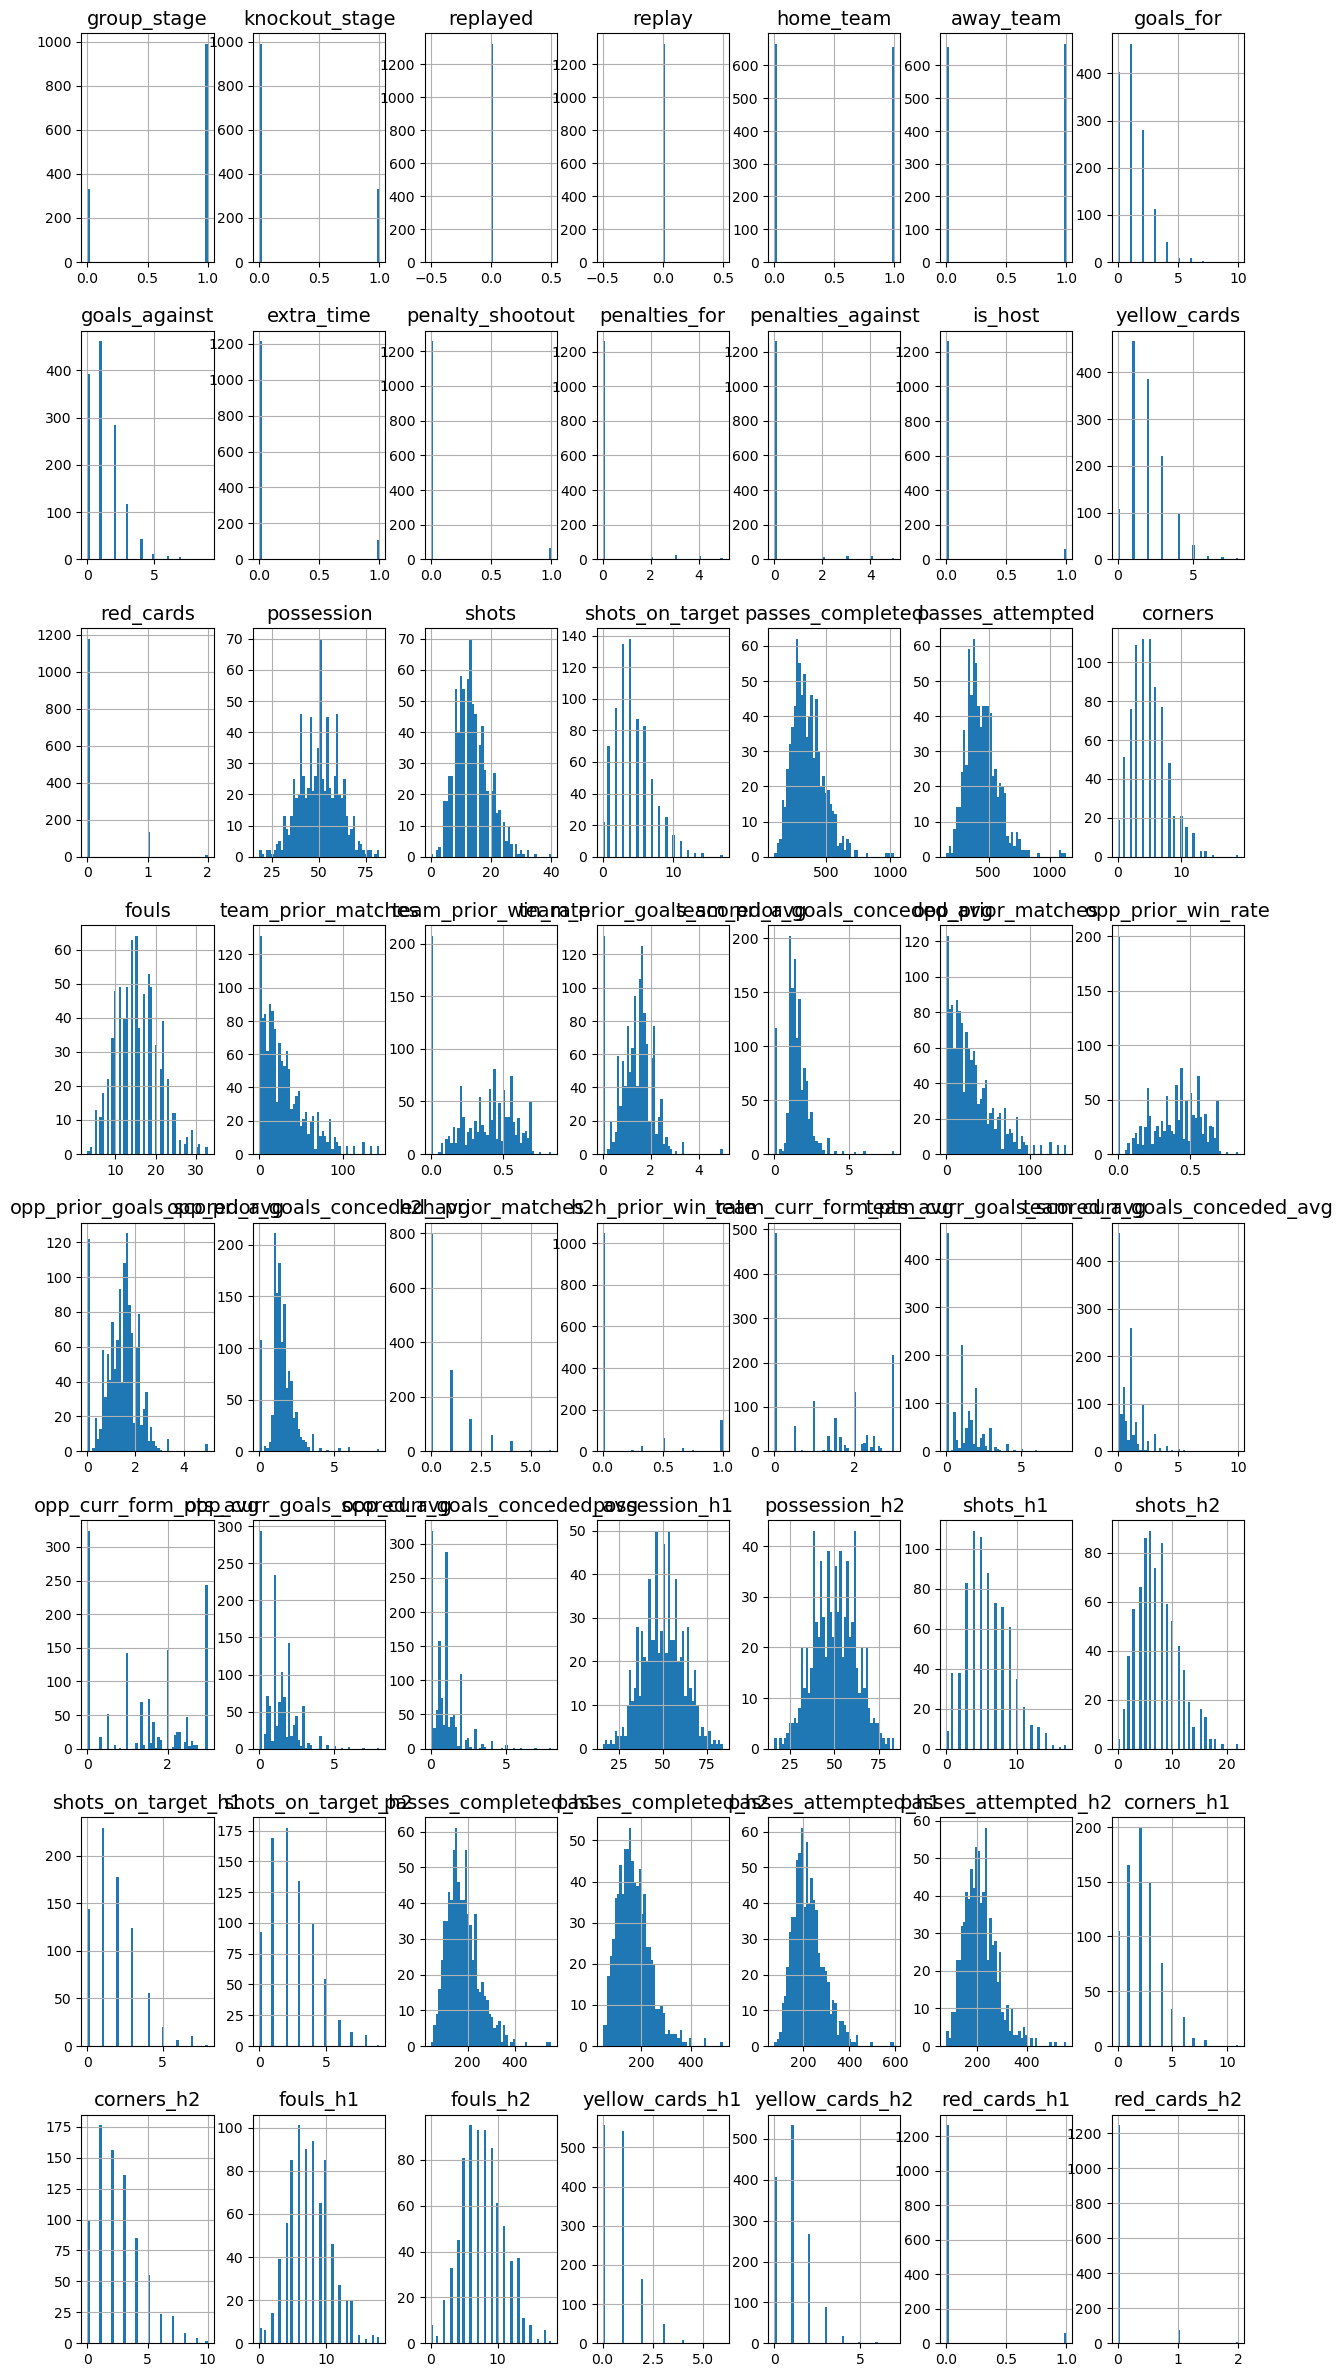

In [7]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

all_data.hist(bins=50, figsize=(15, 30))
plt.show()

In [8]:
data_copy = all_data.copy()

Step 8: Look at missing values. Looks like all are between 1970 and 1998.

In [9]:
null_rows_idx = all_data.isnull().any(axis=1)
all_data.loc[null_rows_idx].tail()

,tournament_name,stage_name,group_name,group_stage,knockout_stage,replayed,replay,match_date,match_time,stadium_name,city_name,country_name,team_name,team_code,opponent_name,opponent_code,home_team,away_team,goals_for,goals_against,extra_time,penalty_shootout,penalties_for,penalties_against,result,is_host,yellow_cards,red_cards,possession,shots,shots_on_target,passes_completed,passes_attempted,corners,fouls,team_prior_matches,team_prior_win_rate,team_prior_goals_scored_avg,team_prior_goals_conceded_avg,opp_prior_matches,opp_prior_win_rate,opp_prior_goals_scored_avg,opp_prior_goals_conceded_avg,h2h_prior_matches,h2h_prior_win_rate,team_curr_form_pts_avg,team_curr_goals_scored_avg,team_curr_goals_conceded_avg,opp_curr_form_pts_avg,opp_curr_goals_scored_avg,opp_curr_goals_conceded_avg,possession_h1,possession_h2,shots_h1,shots_h2,shots_on_target_h1,shots_on_target_h2,passes_completed_h1,passes_completed_h2,passes_attempted_h1,passes_attempted_h2,corners_h1,corners_h2,fouls_h1,fouls_h2,yellow_cards_h1,yellow_cards_h2,red_cards_h1,red_cards_h2,outcome
549,1998 FIFA Men's World Cup,semi-finals,not applicable,0,1,0,0,1998-07-08,21:00,Stade de France,Saint-Denis,France,Croatia,HRV,France,FRA,0,1,1,2,0,0,0,0,lose,0,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.000000,0.000000,34,0.470588,2.088235,1.647059,0,0.0,2.400000,1.600000,0.400000,3.000000,2.000000,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,0.0,0.0,Loss
550,1998 FIFA Men's World Cup,third-place match,not applicable,0,1,0,0,1998-07-11,21:00,Parc des Princes,Paris,France,Netherlands,NLD,Croatia,HRV,1,0,1,2,0,0,0,0,lose,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,0.440000,1.720000,1.160000,0,0.000000,0.000000,0.000000,0,0.0,1.833333,2.000000,0.833333,2.000000,1.500000,0.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0,0.0,0.0,Loss
551,1998 FIFA Men's World Cup,third-place match,not applicable,0,1,0,0,1998-07-11,21:00,Parc des Princes,Paris,France,Croatia,HRV,Netherlands,NLD,0,1,2,1,0,0,0,0,win,0,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,0.000000,0.000000,25,0.440000,1.720000,1.160000,0,0.0,2.000000,1.500000,0.666667,1.571429,1.857143,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,0.0,0.0,Win
552,1998 FIFA Men's World Cup,final,not applicable,0,1,0,0,1998-07-12,21:00,Stade de France,Saint-Denis,France,Brazil,BRA,France,FRA,1,0,0,3,0,0,0,0,lose,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79,0.658228,2.063291,1.050633,34,0.470588,2.088235,1.647059,2,0.5,2.500000,2.333333,1.166667,3.000000,2.000000,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,Loss
553,1998 FIFA Men's World Cup,final,not applicable,0,1,0,0,1998-07-12,21:00,Stade de France,Saint-Denis,France,France,FRA,Brazil,BRA,0,1,3,0,0,0,0,0,win,1,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,0.470588,2.088235,1.647059,79,0.658228,2.063291,1.050633,2,0.5,3.000000,2.000000,0.333333,2.142857,2.000000,1.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,0.0,1.0,Win


Step 9: Look at target variable, outcome

outcome
Loss    540
Win     523
Draw    259
Name: count, dtype: int64
outcome
Loss    540
Win     523
Draw    259
Name: count, dtype: int64
Target percentage:
outcome
Loss    40.847201
Win     39.561271
Draw    19.591528
Name: proportion, dtype: float64


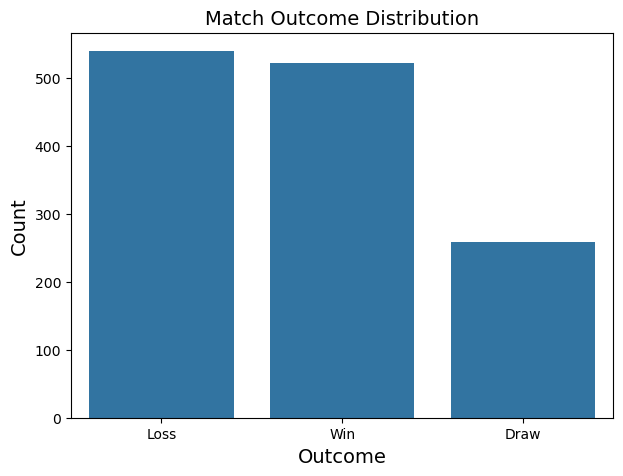

In [10]:
outcome = all_data["outcome"]
print(outcome.value_counts())

target_col = 'outcome'
print(outcome.value_counts())
print('Target percentage:')
print(outcome.value_counts(normalize=True) * 100)

##plot match outcome distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=all_data, x=target_col, order=all_data[target_col].value_counts().index)
plt.title('Match Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

Step 10: Remove columns that are all zeros (replayed, replay)

In [11]:
all_data = all_data.drop(["replayed", "replay"], axis = 1)

Step 11: Check the columns were removed

In [12]:
all_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 68 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tournament_name                1322 non-null   str    
 1   stage_name                     1322 non-null   str    
 2   group_name                     1322 non-null   str    
 3   group_stage                    1322 non-null   int64  
 4   knockout_stage                 1322 non-null   int64  
 5   match_date                     1322 non-null   str    
 6   match_time                     1322 non-null   str    
 7   stadium_name                   1322 non-null   str    
 8   city_name                      1322 non-null   str    
 9   country_name                   1322 non-null   str    
 10  team_name                      1322 non-null   str    
 11  team_code                      1322 non-null   str    
 12  opponent_name                  1322 non-null   str    
 13 

Step 11: Add column for goal differential. If GD is positive, the team won. If zero, it was a draw. If negative, the team lost

In [13]:
all_data["goal_differential"] = all_data["goals_for"]-all_data["goals_against"]
print(all_data["goal_differential"].head())

0    0
1    0
2   -1
3    3
4    1
Name: goal_differential, dtype: int64


Step 12: Check correlations w/ goal differential. Unsurpsingly, shots on target is the biggest indicator and opponents current goals scored average is the biggest against

In [14]:
corr_matrix = all_data.corr(numeric_only=True)
corr_matrix["goal_differential"].sort_values(ascending=False)

goal_differential                1.000000
goals_for                        0.740659
shots_on_target                  0.475445
shots_on_target_h1               0.395385
shots_on_target_h2               0.352203
shots_h1                         0.320117
shots                            0.254326
team_prior_matches               0.244449
team_prior_win_rate              0.241331
team_prior_goals_scored_avg      0.240231
opp_curr_goals_conceded_avg      0.223439
possession_h1                    0.223137
passes_completed_h1              0.188961
passes_attempted_h1              0.185230
corners_h1                       0.176445
home_team                        0.166141
possession                       0.142688
passes_completed                 0.140203
passes_attempted                 0.129380
corners                          0.119854
team_curr_form_pts_avg           0.116201
shots_h2                         0.114637
team_curr_goals_scored_avg       0.093278
passes_completed_h2              0

Step 13: want to add a few more columns: pass completion percentage, percentage of shots on target, shots on target per time of possession

In [15]:
all_data["pass_completion_percentage"] = all_data["passes_completed"]/all_data["passes_attempted"]
all_data["shot_on_goal_percentage"] = all_data["shots_on_target"]/all_data["shots"]
all_data["shot_per_possession_percentage"] = all_data["shots_on_target"]/all_data["possession"]
all_data["team_avg_goals_diff"] = all_data["team_prior_goals_scored_avg"]-all_data["team_prior_goals_conceded_avg"]
all_data["0pp_avg_opp_goals_diff"] = all_data["opp_prior_goals_scored_avg"]-all_data["opp_prior_goals_conceded_avg"]


In [16]:
corr_matrix = all_data.corr(numeric_only=True)
corr_matrix["goal_differential"].sort_values(ascending=False)

goal_differential                 1.000000
goals_for                         0.740659
shots_on_target                   0.475445
shot_per_possession_percentage    0.451662
shot_on_goal_percentage           0.407542
shots_on_target_h1                0.395385
shots_on_target_h2                0.352203
shots_h1                          0.320117
shots                             0.254326
team_prior_matches                0.244449
team_prior_win_rate               0.241331
team_prior_goals_scored_avg       0.240231
opp_curr_goals_conceded_avg       0.223439
possession_h1                     0.223137
passes_completed_h1               0.188961
passes_attempted_h1               0.185230
team_avg_goals_diff               0.181734
corners_h1                        0.176445
home_team                         0.166141
possession                        0.142688
passes_completed                  0.140203
passes_attempted                  0.129380
corners                           0.119854
team_curr_f

Step 14: deal with nan values. I want to experiment with using an iterative imputer for this to see how it works

In [17]:
numerical_data = all_data.select_dtypes(include=[np.number])

In [18]:
from sklearn.experimental import enable_iterative_imputer # Enable experimental feature
from sklearn.impute import IterativeImputer

iterative_imputer = IterativeImputer(max_iter=10, random_state=0)
numerical_vals_imputed = iterative_imputer.fit_transform(numerical_data)




In [19]:
numerical_iterative_imputer = pd.DataFrame(numerical_vals_imputed, columns=numerical_data.columns,
                          index=numerical_data.index)

print("\nImputed Data:\n", numerical_iterative_imputer.head())


Imputed Data:
    group_stage  knockout_stage  home_team  away_team  goals_for  \
0          1.0             0.0        1.0        0.0        0.0   
1          1.0             0.0        0.0        1.0        0.0   
2          1.0             0.0        0.0        1.0        0.0   
3          1.0             0.0        1.0        0.0        4.0   
4          1.0             0.0        1.0        0.0        2.0   

   goals_against  extra_time  penalty_shootout  penalties_for  \
0            0.0         0.0               0.0            0.0   
1            0.0         0.0               0.0            0.0   
2            1.0         0.0               0.0            0.0   
3            1.0         0.0               0.0            0.0   
4            1.0         0.0               0.0            0.0   

   penalties_against  is_host  yellow_cards  red_cards  possession      shots  \
0                0.0      1.0           1.0        0.0   51.669646  13.558536   
1                0.0      0.

In [20]:
numerical_iterative_imputer.loc[null_rows_idx].head()

,group_stage,knockout_stage,home_team,away_team,goals_for,goals_against,extra_time,penalty_shootout,penalties_for,penalties_against,is_host,yellow_cards,red_cards,possession,shots,shots_on_target,passes_completed,passes_attempted,corners,fouls,team_prior_matches,team_prior_win_rate,team_prior_goals_scored_avg,team_prior_goals_conceded_avg,opp_prior_matches,opp_prior_win_rate,opp_prior_goals_scored_avg,opp_prior_goals_conceded_avg,h2h_prior_matches,h2h_prior_win_rate,team_curr_form_pts_avg,team_curr_goals_scored_avg,team_curr_goals_conceded_avg,opp_curr_form_pts_avg,opp_curr_goals_scored_avg,opp_curr_goals_conceded_avg,possession_h1,possession_h2,shots_h1,shots_h2,shots_on_target_h1,shots_on_target_h2,passes_completed_h1,passes_completed_h2,passes_attempted_h1,passes_attempted_h2,corners_h1,corners_h2,fouls_h1,fouls_h2,yellow_cards_h1,yellow_cards_h2,red_cards_h1,red_cards_h2,goal_differential,pass_completion_percentage,shot_on_goal_percentage,shot_per_possession_percentage,team_avg_goals_diff,0pp_avg_opp_goals_diff
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,51.669646,13.558536,4.287724,346.363319,433.497441,5.163612,15.427495,17.0,0.058824,0.764706,2.705882,15.0,0.533333,1.600000,1.266667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.821739,52.251276,5.683945,7.635848,1.540382,2.569506,175.436300,172.250562,221.829317,216.031671,2.455322,2.477730,7.071101,8.009655,0.0,1.0,0.0,0.0,0.0,0.786911,0.302321,0.080820,-1.941176,0.333333
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,51.991201,14.228255,3.875739,347.864954,437.453056,5.053592,16.924435,15.0,0.533333,1.600000,1.266667,17.0,0.058824,0.764706,2.705882,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,52.536895,51.814135,6.374246,7.783581,1.599410,2.259802,179.829936,165.772787,224.081770,211.734274,2.607645,2.462169,9.042488,7.485226,3.0,1.0,0.0,0.0,0.0,0.780234,0.273534,0.074513,0.333333,-1.941176
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,51.473245,14.308136,3.835249,349.316407,436.569842,5.191742,14.218222,16.0,0.500000,2.375000,2.187500,20.0,0.600000,1.900000,1.100000,1.0,1.0,0.0,0.0,0.0,3.0,1.0,0.0,50.726526,52.478320,6.315444,7.942003,1.778877,2.049985,176.026045,171.598499,221.276469,215.421684,2.444721,2.750706,6.519419,6.888818,0.0,1.0,0.0,0.0,-1.0,0.789670,0.266877,0.074419,0.187500,0.800000
3,1.0,0.0,1.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,50.356527,12.109911,4.938352,352.919727,436.317339,4.501374,13.038013,32.0,0.625000,2.625000,1.312500,19.0,0.421053,1.578947,1.526316,4.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,52.535979,48.174420,6.430525,6.223039,2.505314,2.600375,183.503309,172.588651,227.786846,216.170055,2.444455,2.031377,6.559324,6.199672,1.0,0.0,0.0,0.0,3.0,0.794893,0.400243,0.100899,1.312500,0.052632
4,1.0,0.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,50.027172,13.297952,4.697190,347.883466,433.464076,4.713919,14.901698,5.0,0.200000,1.600000,2.400000,19.0,0.421053,1.578947,1.526316,1.0,0.0,0.0,0.0,1.0,0.0,1.0,4.0,49.554223,50.152489,5.903144,7.501258,1.943189,2.714868,179.145105,171.880811,224.469638,216.278469,2.217312,2.568793,7.303230,7.837164,0.0,1.0,0.0,0.0,1.0,0.791260,0.349165,0.095024,-0.800000,0.052632


Step 15: try to deal with the string values now. I'll use a labelencoder for the outcome, the others will use onehotencoding

In [21]:
data_labels = all_data.select_dtypes(exclude=[np.number])
data_labels.info()
result = data_labels.filter(['result'])
data_labels = data_labels.drop(['outcome'], axis = 1)
data_labels = data_labels.drop(['result'], axis = 1)
result.head()
data_labels.info()


<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   tournament_name  1322 non-null   str  
 1   stage_name       1322 non-null   str  
 2   group_name       1322 non-null   str  
 3   match_date       1322 non-null   str  
 4   match_time       1322 non-null   str  
 5   stadium_name     1322 non-null   str  
 6   city_name        1322 non-null   str  
 7   country_name     1322 non-null   str  
 8   team_name        1322 non-null   str  
 9   team_code        1322 non-null   str  
 10  opponent_name    1322 non-null   str  
 11  opponent_code    1322 non-null   str  
 12  result           1322 non-null   str  
 13  outcome          1322 non-null   str  
dtypes: str(14)
memory usage: 144.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 1322 entries, 0 to 1321
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------          

step 16: Grab the categories of interest

In [22]:
print(numerical_data.columns)
#pre_game_numerical_categories = ['group_stage', 'knockout_stage', 'home_team', 'away_team', 'goals_for',
#       'goals_against', 'extra_time', 'penalty_shootout', 'penalties_for',
#       'penalties_against', 'is_host', 'yellow_cards', 'red_cards',
#       'possession', 'shots', 'shots_on_target', 'passes_completed',
#       'passes_attempted', 'corners', 'fouls', 'team_prior_matches',
#       'team_prior_win_rate', 'team_prior_goals_scored_avg',
#       'team_prior_goals_conceded_avg', 'opp_prior_matches',
#       'opp_prior_win_rate', 'opp_prior_goals_scored_avg',
#       'opp_prior_goals_conceded_avg', 'h2h_prior_matches',
#       'h2h_prior_win_rate', 'team_curr_form_pts_avg',
#       'team_curr_goals_scored_avg', 'team_curr_goals_conceded_avg',
#       'opp_curr_form_pts_avg', 'opp_curr_goals_scored_avg',
#       'opp_curr_goals_conceded_avg', 'pass_completion_percentage',
#       'shot_on_goal_percentage', 'shot_per_possession_percentage' ]

pre_game_numerical_categories = ['group_stage', 'knockout_stage', 'home_team', 'away_team', 'extra_time', 'penalty_shootout', 'penalties_for',
       'penalties_against', 'is_host', 'yellow_cards', 'red_cards',
       'team_prior_matches', 'team_prior_win_rate', 'team_prior_goals_scored_avg',
       'team_prior_goals_conceded_avg', 'opp_prior_matches',
       'opp_prior_win_rate', 'opp_prior_goals_scored_avg',
       'opp_prior_goals_conceded_avg', 'h2h_prior_matches',
       'h2h_prior_win_rate', 'team_curr_form_pts_avg',
       'team_curr_goals_scored_avg', 'team_curr_goals_conceded_avg',
       'opp_curr_form_pts_avg', 'opp_curr_goals_scored_avg',
       'opp_curr_goals_conceded_avg']

categorical_categories = [ 'stage_name', 'team_name', 'team_code', 'opponent_name', 'opponent_code']

features = [col for col in pre_game_numerical_categories + categorical_categories if col in all_data.columns]
X = all_data[features]
y = all_data[target_col]
print(len(features))

Index(['group_stage', 'knockout_stage', 'home_team', 'away_team', 'goals_for',
       'goals_against', 'extra_time', 'penalty_shootout', 'penalties_for',
       'penalties_against', 'is_host', 'yellow_cards', 'red_cards',
       'possession', 'shots', 'shots_on_target', 'passes_completed',
       'passes_attempted', 'corners', 'fouls', 'team_prior_matches',
       'team_prior_win_rate', 'team_prior_goals_scored_avg',
       'team_prior_goals_conceded_avg', 'opp_prior_matches',
       'opp_prior_win_rate', 'opp_prior_goals_scored_avg',
       'opp_prior_goals_conceded_avg', 'h2h_prior_matches',
       'h2h_prior_win_rate', 'team_curr_form_pts_avg',
       'team_curr_goals_scored_avg', 'team_curr_goals_conceded_avg',
       'opp_curr_form_pts_avg', 'opp_curr_goals_scored_avg',
       'opp_curr_goals_conceded_avg', 'possession_h1', 'possession_h2',
       'shots_h1', 'shots_h2', 'shots_on_target_h1', 'shots_on_target_h2',
       'passes_completed_h1', 'passes_completed_h2', 'passes_attemp

Step 17: Setup the pipeline

In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', iterative_imputer),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, pre_game_numerical_categories),
        ('cat', categorical_transformer, categorical_categories)
    ]
)


#print(y_encoded.head())
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

Step 18: Get training and test sets

In [24]:
X_train, X_test, y_train, y_test = train_test_split( X, y_encoded, test_size=0.2,  random_state=4, stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1057, 32)
(265, 32)
(1057,)
(265,)


Step 19: Define the models and train. I want to look at this more closely to see if I can improve these at all

In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVC': SVC(probability=True, random_state=RANDOM_STATE)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_Macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall_Macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1_Macro': f1_score(y_test, y_pred, average='macro', zero_division=0)
    })
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('F1_Macro', ascending=False)
results_df

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
2,Gradient Boosting,0.656604,0.654550,0.623864,0.632119
4,SVC,0.667925,0.662517,0.606797,0.612521
1,Random Forest,0.660377,0.661115,0.603772,0.611646
3,KNN,0.618868,0.596585,0.581970,0.586525
0,Logistic Regression,0.607547,0.561863,0.552856,0.553563


Step 20: Identify the best model

In [26]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_pipelines[best_model_name]
print('Best Model:', best_model_name)

Best Model: Gradient Boosting


Step 21: Show the prediction for the test, and classify the performance based on percision and recall of the classification model

In [27]:


y_pred_best = best_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_,
    zero_division=0
))



              precision    recall  f1-score   support

        Draw       0.63      0.46      0.53        52
        Loss       0.71      0.65      0.68       108
         Win       0.62      0.76      0.69       105

    accuracy                           0.66       265
   macro avg       0.65      0.62      0.63       265
weighted avg       0.66      0.66      0.65       265



Step 22: testing extreme gradient boosting (first try with this, may need some work)

In [35]:
for cat in categorical_categories:
    X_train[cat] = X_train[cat].astype('category')
    X_test[cat] = X_test[cat].astype('category')


In [38]:
from sklearn.preprocessing import MinMaxScaler

y_train = y_train.reshape(-1, 1)
y_test= y_test.reshape(-1, 1)


min_max_scaler = MinMaxScaler(feature_range = (0,1))
y_train = min_max_scaler.fit_transform(y_train)
y_test = min_max_scaler.transform(y_test)


xgb_train = xgb.DMatrix(X_train, y_train, enable_categorical=True)
xgb_test = xgb.DMatrix(X_test, y_test, enable_categorical=True)

params = {
    'objective': 'binary:logistic',
    'max_depth': 100,
    'learning_rate': 0.01,
}
n=100
model = xgb.train(params=params,dtrain=xgb_train,num_boost_round=n)

In [39]:
preds = model.predict(xgb_test)
preds = np.round(preds)
y_test = min_max_scaler.inverse_transform(y_test)
accuracy= accuracy_score(y_test,preds)
print('Accuracy of the model is:', accuracy*100)

Accuracy of the model is: 42.26415094339623
